## **Part 1: BBC Urdu Dataset Collection and Preprocessing**
In this part, BBC Urdu news articles are collected and prepared into a clean dataset using normalization and custom preprocessing tools. The output of this part will be reused directly in Part 2.

News articles scraped from:
https://www.bbc.com/urdu


Article metadata must be stored in a JSON file with the following constraints:
- Each article must be numbered
- Article numbers must be unique
- Article numbers must match TXT files
- Article body must not be included

### ***Format Example***
```json
{
  "1": {
    "title": "پاکستان میں مہنگائی کی شرح میں اضافہ",
    "publish_date": "2024-01-15"
  },
  "2": {
    "title": "کراچی میں بارش کے بعد صورتحال",
    "publish_date": "2024-02-02"
  }
}

In [ ]:
import requests
from bs4 import BeautifulSoup
import json
import time

BASE_URL = "https://www.bbc.com"
START_URL = "https://www.bbc.com/urdu"

HEADERS = {"User-Agent": "Mozilla/5.0"}

MAX_ARTICLES = 220

visited_links = set()
metadata = {}
article_id = 1


def get_soup(url):
    try:
        response = requests.get(url, headers=HEADERS, timeout=10)
        if response.status_code == 200:
            return BeautifulSoup(response.text, "html.parser")
    except:
        return None
    return None


def extract_article_links(page_url):
    soup = get_soup(page_url)
    links = []

    if not soup:
        return links

    for a in soup.find_all("a", href=True):
        href = a["href"]

        if "/urdu/articles/" in href:
            full_link = BASE_URL + href if href.startswith("/") else href
            links.append(full_link)

    return list(set(links))


def extract_metadata(article_url):
    soup = get_soup(article_url)
    if not soup:
        return None, None

    title_tag = soup.find("h1")
    title = title_tag.get_text(strip=True) if title_tag else None

    time_tag = soup.find("time")
    publish_date = None
    if time_tag and time_tag.has_attr("datetime"):
        publish_date = time_tag["datetime"][:10]

    return title, publish_date


print("Collecting topic pages...")

soup = get_soup(START_URL)
topic_urls = []

for a in soup.find_all("a", href=True):
    href = a["href"]
    if "/urdu/topics/" in href:
        full_link = BASE_URL + href if href.startswith("/") else href
        topic_urls.append(full_link)

topic_urls = list(set(topic_urls))

print(f"Found {len(topic_urls)} topic sections.")


for topic_url in topic_urls:
    page_number = 1

    while article_id <= MAX_ARTICLES:
        paginated_url = topic_url + f"?page={page_number}"

        links = extract_article_links(paginated_url)

        if not links:
            break

        for link in links:
            if article_id > MAX_ARTICLES:
                break

            if link in visited_links:
                continue

            title, publish_date = extract_metadata(link)

            if title and publish_date:
                metadata[str(article_id)] = {
                    "title": title,
                    "publish_date": publish_date,
                    "url": link
                }

                print(f"Collected Article {article_id}")
                article_id += 1
                visited_links.add(link)

                time.sleep(1)

        page_number += 1


print(f"\nTotal Articles Collected: {len(metadata)}")

with open("Metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("Metadata.json saved successfully!")


Found 7 topic sections.
Collected Article 1
Collected Article 2
Collected Article 3
Collected Article 4
Collected Article 5
Collected Article 6
Collected Article 7
Collected Article 8
Collected Article 9
Collected Article 10
Collected Article 11
Collected Article 12
Collected Article 13
Collected Article 14
Collected Article 15
Collected Article 16
Collected Article 17
Collected Article 18
Collected Article 19
Collected Article 20
Collected Article 21
Collected Article 22
Collected Article 23
Collected Article 24
Collected Article 25
Collected Article 26
Collected Article 27
Collected Article 28
Collected Article 29
Collected Article 30
Collected Article 31
Collected Article 32
Collected Article 33
Collected Article 34
Collected Article 35
Collected Article 36
Collected Article 37
Collected Article 38
Collected Article 39
Collected Article 40
Collected Article 41
Collected Article 42
Collected Article 43
Collected Article 44
Collected Article 45
Collected Article 46
Collected Article 4

In [ ]:
print(f"Total articles collected: {len(metadata)}")
assert 200 <= len(metadata) <= 300, "Must have 200-300 articles"

# Verify JSON structure
sample = list(metadata.items())[:3]
for key, value in sample:
    assert 'title' in value, "Must have title"
    assert 'publish_date' in value, "Must have publish_date"
    assert 'body' not in value, "Must NOT have body in JSON"
    print(f"Article {key}: {value['title']}")

Total articles collected: 220
Article 1: بنگلہ دیش اور امریکہ کے تجارتی معاہدے کو انڈیا کے لیے ’خطرناک‘ کیوں قرار دیا جا رہا ہے؟
Article 2: ’دہلی نہیں، ڈھاکہ‘: بنگلہ دیش کی نوجوان نسل میں ’انڈیا مخالف جذبات‘ کیوں بڑھ رہے ہیں؟
Article 3: اسلام آباد کی ’ہمدرد‘ سمجھی جانے والی جماعت کی کامیابی: بنگلہ دیش کے انتخابی نتائج پاکستان اور انڈیا کے لیے کیا معنی رکھتے ہیں؟


### ***raw.txt File***
This file must contain:
- Raw scraped article content
- No cleaning or normalization
- One article per block
- Each article must start with its article number

### ***Example***
```json
[1]
یہ خبر بی بی سی اردو سے حاصل کی گئی ہے...

[2]
کراچی میں بارش کے بعد صورتحال خراب ہو گئی...

In [ ]:
HEADERS = {"User-Agent": "Mozilla/5.0"}

def get_soup(url):
    try:
        response = requests.get(url, headers=HEADERS, timeout=10)
        if response.status_code == 200:
            return BeautifulSoup(response.text, "html.parser")
    except:
        return None
    return None


def extract_article_body(url):
    soup = get_soup(url)
    if not soup:
        return None

    article_body = []

    # BBC Urdu article paragraphs are inside <p> tags
    paragraphs = soup.find_all("p")

    for p in paragraphs:
        text = p.get_text(strip=True)
        if text:
            article_body.append(text)

    return "\n".join(article_body)

with open("Metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)


with open("raw.txt", "w", encoding="utf-8") as raw_file:

    for article_id in sorted(metadata.keys(), key=lambda x: int(x)):

        url = metadata[article_id]["url"]

        print(f"Extracting Article {article_id}")

        body = extract_article_body(url)

        if body:
            raw_file.write(f"[{article_id}]\n")
            raw_file.write(body)
            raw_file.write("\n\n")

            time.sleep(1)  # polite delay


print("raw.txt created successfully!")


Extracting Article 1
Extracting Article 2
Extracting Article 3
Extracting Article 4
Extracting Article 5
Extracting Article 6
Extracting Article 7
Extracting Article 8
Extracting Article 9
Extracting Article 10
Extracting Article 11
Extracting Article 12
Extracting Article 13
Extracting Article 14
Extracting Article 15
Extracting Article 16
Extracting Article 17
Extracting Article 18
Extracting Article 19
Extracting Article 20
Extracting Article 21
Extracting Article 22
Extracting Article 23
Extracting Article 24
Extracting Article 25
Extracting Article 26
Extracting Article 27
Extracting Article 28
Extracting Article 29
Extracting Article 30
Extracting Article 31
Extracting Article 32
Extracting Article 33
Extracting Article 34
Extracting Article 35
Extracting Article 36
Extracting Article 37
Extracting Article 38
Extracting Article 39
Extracting Article 40
Extracting Article 41
Extracting Article 42
Extracting Article 43
Extracting Article 44
Extracting Article 45
Extracting Article 

## ***cleaned.txt File***

This file must contain:
- Fully preprocessed data
- Normalized Urdu text
- Noise removed
- Sentence segmented
- Ready for language model training
- Article numbering matching raw.txt and JSON

**Refer to the given Assignment PDF Document for the data cleaning and normalizing techniques**

In [ ]:

with open("raw.txt", "r", encoding="utf-8") as f:
    raw_data = f.read()

print("Raw file loaded successfully.")
print(f"Raw data length: {len(raw_data)} characters")


Raw file loaded successfully.
Raw data length: 1519359 characters


In [ ]:
import re

### **Diacritics Removal**

In [ ]:
def remove_diacritics(text):
    diacritics_pattern = (
        r'[\u064E'  # Zabar
        r'\u0650'   # Zer
        r'\u064F'   # Pesh
        r'\u0652'   # Jazm
        r'\u0651'   # Tashdeed
        r'\u0670'   # Khari Zabar
        r'\u0654'   # Hamza Above
        r'\u0653'   # Madda
        r'\u0658'   # Noon Ghunna
        r']'
    )
    return re.sub(diacritics_pattern, '', text)

step1 = remove_diacritics(raw_data)

print("Diacritics removed.")



Diacritics removed.


### **Noise Removal**

**URL remover**

In [ ]:
def remove_urls(text):
    url_pattern = r'https?://\S+|www\.\S+|\S+\.\S{2,}(?:\s|$)'
    return re.sub(url_pattern, '', text)


step2 = remove_urls(step1)

print("URLs removed.")


URLs removed.


**Emojis and symbol remover**

In [ ]:
import emoji
def remove_emojis_and_symbols(text):
    text = emoji.replace_emoji(text, replace='')
    return re.sub(r'[^\u0600-\u06FF0-9\s۔؟!،]', '', text)
step3 = remove_emojis_and_symbols(step2)
print("emojis removed")

emojis removed


**Remove Navigation Text**

In [ ]:
def remove_navigation_text(text: str) -> str:
    nav_pattern = r'\b(Home|News|Sports|Entertainment|Video|Live|BBC Urdu)\b'
    text = re.sub(nav_pattern, '', text, flags=re.IGNORECASE)
    return text

step4 = remove_navigation_text(step3)
print("Navigation text removed.")


Navigation text removed.


**English Sentences**

In [ ]:
def remove_english(text: str) -> str:
    return re.sub(r'[A-Za-z]+', '', text)

step5 = remove_english(step4)
print("English sentences removed.")


English sentences removed.


**Roman Urdu**

In [ ]:
def remove_roman_urdu(text: str) -> str:
    return re.sub(r'\b[a-zA-Z]+\b', '', text)

step6 = remove_roman_urdu(step5)
print("Roman Urdu removed.")


Roman Urdu removed.


**Sentence Segmentation**

In [ ]:
def segment_sentences(text):
    text = re.sub(r'([۔.؟!])', r' \1 ', text)
    sentences = re.split(r'(?<=[۔.؟!])\s+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    return '\n'.join(sentences)

step7 = segment_sentences(step6)
print(" Sentence segmentation complete (punctuation preserved).")

 Sentence segmentation complete (punctuation preserved).


**Whitespace Normalization**

In [ ]:
def normalize_whitespace(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip()

cleaned_text = normalize_whitespace(step7)
print("Whitespace normalized.")


Whitespace normalized.


In [ ]:
with open("cleaned.txt", "w", encoding="utf-8") as f:
    f.write(cleaned_text)

print("cleaned.txt saved successfully.")


cleaned.txt saved successfully.


## ***Custom Urdu Tokenizer***

The tokenizer must handle:
- Word boundaries
- Punctuation
- Postpositions
- Numbers and special tokens

All numbers must be replaced with `<NUM>`.

Input:

پاکستان میں میں بارش ہوئی  
2024  

Output:

پاکستان | میں | میں | بارش | ہوئی  
`<NUM>`

In [ ]:
def urdu_tokenizer(text):

    # (remove [ID] markers)
    text = re.sub(r'\[\d+\]\n', '', text)
    text = re.sub(r'\d+', ' <NUM> ', text)

    # Ensuring punctuation has spaces around it
    text = re.sub(r'([۔.؟!،])', r' \1 ', text)
    sentences = re.split(r'[۔.؟!]\s+', text)

    tokens = []
    for sentence in sentences:
        words = sentence.strip().split()
        if words:
            tokens.append('<s>')
            tokens.extend(words)
            tokens.append('</s>')

    return tokens

with open("cleaned.txt", "r", encoding="utf-8") as f:
    cleaned_text = f.read()

tokenized_data = urdu_tokenizer(cleaned_text)
print(f"\nTokenization complete. Total tokens: {len(tokenized_data)}")
print(f"  Number of sentences: {tokenized_data.count('<s>')}")

with open("tokenized.txt", "w", encoding="utf-8") as f:
    f.write(' '.join(tokenized_data))
print("tokenized.txt saved successfully.")



Tokenization complete. Total tokens: 351041
  Number of sentences: 12066
tokenized.txt saved successfully.


## ***Custom Urdu Stemmer***
The stemmer must remove common Urdu suffixes.

Input:
لڑکیوں نے کتابیں پڑھیں  

Output:
لڑکی | کتاب | پڑھ


In [ ]:
URDU_SUFFIXES = [
    'یاں', 'ئیں', 'گان', 'انہ', 'دار', 'ناک', 'مند', 'ہار', 'ائی', 'اہٹ',
    'انی', 'تے', 'تی', 'تا', 'نا', 'ئے', 'نے', 'کا', 'کے', 'کی', 'چہ', 'پن', 'پا',
    'وں', 'ان', 'ات', 'یں', 'ون', 'ہا', 'نی', 'یہ',
    'ی', 'ے', 'ا', 'ہ', 'ت'
]


In [ ]:
def urdu_stemmer(tokens):

    stemmed = []

    for token in tokens:
        # Preserve special tokens
        if token in ['<s>', '</s>', '<NUM>']:
            stemmed.append(token)
            continue
        if len(token) <= 3:
            stemmed.append(token)
            continue
        stemmed_token = token
        for suffix in sorted(URDU_SUFFIXES, key=len, reverse=True):
            if token.endswith(suffix) and len(token) > len(suffix) + 2:
                stemmed_token = token[:-len(suffix)]
                break

        stemmed.append(stemmed_token)

    return stemmed

stemmed_data = urdu_stemmer(tokenized_data)
print(f"\nStemming complete. Total tokens: {len(stemmed_data)}")

with open("stemmed.txt", "w", encoding="utf-8") as f:
    f.write(' '.join(stemmed_data))
print("stemmed.txt saved successfully.")



Stemming complete. Total tokens: 351041
stemmed.txt saved successfully.


## ***Custom Urdu Lemmatizer***

The lemmatizer is restricted to:
- Plural normalization
- Gender normalization

Plural:
- لڑکیاں -> لڑکی  
- کتابوں -> کتاب  

Gender:
- اچھی -> اچھا  
- بڑی -> بڑا

In [ ]:

PLURAL_MAP = {
    'لڑکے':'لڑکا', 'لڑکیاں':'لڑکی', 'لڑکیں':'لڑکی', 'لڑکوں':'لڑکا',
    'بچے':'بچہ', 'بچوں':'بچہ', 'بچیاں':'بچی', 'بچیں':'بچی',
    'لوگ':'شخص', 'لوگوں':'شخص', 'آدمیوں':'آدمی', 'مردوں':'مرد', 'عورتیں':'عورت', 'عورتوں':'عورت',
    'خواتین':'خاتون', 'بیٹے':'بیٹا', 'بیٹوں':'بیٹا', 'بیٹیاں':'بیٹی', 'بیٹیں':'بیٹی', 'بیٹیوں':'بیٹی',
    'بہنوں':'بہن', 'بہنیں':'بہن', 'ماؤں':'ماں', 'والدین':'والد',
    'کتابیں':'کتاب', 'کتابوں':'کتاب', 'کتابات':'کتاب', 'قلمیں':'قلم', 'قلموں':'قلم', 'کاپیاں':'کاپی', 'کاپیوں':'کاپی',
    'جگہیں':'جگہ', 'جگہوں':'جگہ', 'مکانوں':'مکان', 'مکانات':'مکان', 'شہروں':'شہر', 'ایام':'دن', 'راتیں':'رات', 'راتوں':'رات',
    'سالوں':'سال', 'برسوں':'برس', 'مہینوں':'مہینہ', 'گھنٹوں':'گھنٹہ', 'ہاتھوں':'ہاتھ', 'آنکھوں':'آنکھ', 'کانوں':'کان',
    'اساتذہ':'استاد', 'طلباء':'طالب', 'طالبات':'طالبہ', 'ڈاکٹروں':'ڈاکٹر', 'انجینئروں':'انجینئر', 'واقعات':'واقعہ', 'خبریں':'خبر',
    'کہانیاں':'کہانی', 'چیزیں':'چیز', 'چیزوں':'چیز', 'اشیاء':'چیز', 'کاموں':'کام', 'باتیں':'بات', 'باتوں':'بات', 'گھروں':'گھر', 'پیر':'پاؤں'
}

GENDER_MAP = {
    'اچھی':'اچھا', 'اچھے':'اچھا', 'بڑی':'بڑا', 'بڑے':'بڑا', 'چھوٹی':'چھوٹا', 'چھوٹے':'چھوٹا',
    'نئی':'نیا', 'نئے':'نیا', 'پرانی':'پرانا', 'پرانے':'پرانا', 'خوبصورت':'خوبصورت', 'بدصورت':'بدصورت',
    'کالی':'کالا', 'کالے':'کالا', 'نیلی':'نیلا', 'نیلے':'نیلا', 'ہری':'ہرا', 'ہرے':'ہرا', 'ٹھنڈی':'ٹھنڈا', 'ٹھنڈے':'ٹھنڈا',
    'گیلی':'گیلا', 'گیلے':'گیلا', 'سوکھی':'سوکھا', 'سوکھے':'سوکھا', 'طالبہ':'طالب', 'نوکرانی':'نوکر', 'ڈاکٹرنی':'ڈاکٹر'
}


In [ ]:
def urdu_lemmatizer(tokens):

    lemmatized = []

    for token in tokens:
        if token in ['<s>', '</s>', '<NUM>']:
            lemmatized.append(token)
        elif token in PLURAL_MAP:
            lemmatized.append(PLURAL_MAP[token])
        elif token in GENDER_MAP:
            lemmatized.append(GENDER_MAP[token])
        else:
            lemmatized.append(token)

    return lemmatized

lemmatized_data = urdu_lemmatizer(stemmed_data)
print(f"\nLemmatization complete. Total tokens: {len(lemmatized_data)}")

with open("lemmatized.txt", "w", encoding="utf-8") as f:
    f.write(' '.join(lemmatized_data))
print("lemmatized.txt saved successfully.")


Lemmatization complete. Total tokens: 351041
lemmatized.txt saved successfully.


### ***Mandatory Deliverables for Part 1***
- JSON metadata file
- raw.txt
- cleaned.txt
- Tokenized dataset
- Stemmed dataset
- Lemmatized dataset


In [ ]:
import os

files = ["Metadata.json","raw.txt","cleaned.txt","tokenized.txt","stemmed.txt","lemmatized.txt"]

for f in files:
    status = "yes" if os.path.exists(f) and os.path.getsize(f) > 0 else "no"
    print(f"{f}: {status}")


Metadata.json: yes
raw.txt: yes
cleaned.txt: yes
tokenized.txt: yes
stemmed.txt: yes
lemmatized.txt: yes


## **Part 2: BBC Style Urdu News Article Generation**

Students must implement the following statistical language models:
- Unigram Language Model (for fallback and evaluation purposes)
- Bigram Language Model (for fallback and evaluation purposes)
- Trigram Language Model with fallback (Trigram → Bigram → Unigram)

The article generation system must use a fallback mechanism such that when a higher-order n-gram is unavailable, the model automatically backs off to a lower-order model.

Only Laplace (Add-One) smoothing is allowed for probability estimation.  
No other smoothing methods may be used.

In [ ]:
from collections import defaultdict, Counter
import random
import math


In [ ]:
with open("lemmatized.txt", "r", encoding="utf-8") as f:
    tokens = f.read().split()

print(f"Total tokens loaded: {len(tokens)}")
print(f"Sample tokens: {tokens[:50]}")
print(f"Number of <s> tokens: {tokens.count('<s>')}")
print(f"Number of </s> tokens: {tokens.count('</s>')}")

Total tokens loaded: 351041
Sample tokens: ['<s>', '<NUM>', '،', 'تصویر', 'کا', 'ذریع', 'سوموار', '<NUM>', 'فرور', 'کو', 'امریک', 'اور', 'بنگل', 'دیش', 'نے', 'تقریب', 'نو', 'ماہ', 'تک', 'جار', 'رہن', 'وال', 'مذاکر', 'کے', 'بعد', 'محصول', 'سے', 'متعلق', 'ایک', 'تجار', 'معاہد', 'پر', 'دستخط', 'کیے', 'جس', 'کے', 'تحت', 'امریک', 'نے', 'بنگل', 'دیش', 'پر', 'محصول', '<NUM>', 'فیصد', 'تک', 'کم', 'کرن', 'پر', 'اتفاق']
Number of <s> tokens: 12066
Number of </s> tokens: 12066


In [ ]:
def split_into_sentences(tokens):
    sentences = []
    current_sentence = []

    for token in tokens:
        current_sentence.append(token)
        if token == '</s>':
            if len(current_sentence) > 2:  # At least <s> word </s>
                sentences.append(current_sentence)
            current_sentence = []

    return sentences

def train_test_split(sentences, train_ratio=0.8):
    split_idx = int(len(sentences) * train_ratio)
    train_sentences = sentences[:split_idx]
    test_sentences = sentences[split_idx:]

    train_tokens = [token for sentence in train_sentences for token in sentence]
    test_tokens = [token for sentence in test_sentences for token in sentence]

    return train_tokens, test_tokens, train_sentences, test_sentences

sentences = split_into_sentences(tokens)
print(f"\nTotal sentences: {len(sentences)}")

train_tokens, test_tokens, train_sentences, test_sentences = train_test_split(sentences)
print(f"Training tokens: {len(train_tokens)}")
print(f"Testing tokens: {len(test_tokens)}")
print(f"Training sentences: {len(train_sentences)}")
print(f"Testing sentences: {len(test_sentences)}")


Total sentences: 12066
Training tokens: 281875
Testing tokens: 69166
Training sentences: 9652
Testing sentences: 2414


In [ ]:
def build_ngram_models(tokens):
    # Unigrams
    unigrams = Counter(tokens)

    # Bigrams
    bigrams = defaultdict(Counter)
    for i in range(len(tokens) - 1):
        w1, w2 = tokens[i], tokens[i + 1]
        bigrams[w1][w2] += 1

    # Trigrams
    trigrams = defaultdict(Counter)
    for i in range(len(tokens) - 2):
        w1, w2, w3 = tokens[i], tokens[i + 1], tokens[i + 2]
        trigrams[(w1, w2)][w3] += 1

    # Vocabulary size (for Laplace smoothing)
    vocab = set(tokens)
    V = len(vocab)

    return unigrams, bigrams, trigrams, V, vocab

# Build models
unigrams, bigrams, trigrams, V, vocab = build_ngram_models(train_tokens)
total_unigrams = sum(unigrams.values())

print(f"\nVocabulary size (V): {V}")
print(f"Total unigrams count: {total_unigrams}")
print(f"Unique bigrams: {sum(len(b) for b in bigrams.values())}")
print(f"Unique trigrams: {sum(len(t) for t in trigrams.values())}")


Vocabulary size (V): 8699
Total unigrams count: 281875
Unique bigrams: 82401
Unique trigrams: 172179


In [ ]:
# ================================
# Laplace Smoothing + Backoff
# ================================


def unigram_prob(word):
    return (unigrams.get(word, 0) + 1) / (total_unigrams + V)

def bigram_prob(w1, w2):
    numerator = bigrams.get(w1, {}).get(w2, 0) + 1
    denominator = unigrams.get(w1, 0) + V
    return numerator / denominator

def trigram_prob(w1, w2, w3):
    numerator = trigrams.get((w1, w2), {}).get(w3, 0) + 1
    denominator = bigrams.get(w1, {}).get(w2, 0) + V
    return numerator / denominator

def backoff_probability(w1, w2, w3):
    if (w1, w2) in trigrams and w3 in trigrams[(w1, w2)]:
        return trigram_prob(w1, w2, w3)

    if w2 in bigrams and w3 in bigrams[w2]:
        return bigram_prob(w2, w3)
    return unigram_prob(w3)




In [ ]:
def get_next_word_candidates(context, model_type='trigram'):

    if model_type == 'trigram' and len(context) >= 2:
        w1, w2 = context[-2], context[-1]

        if (w1, w2) in trigrams:
            candidates = list(trigrams[(w1, w2)].keys())
            probs = [trigram_prob(w1, w2, w) for w in candidates]
            return candidates, probs

        if w2 in bigrams:
            candidates = list(bigrams[w2].keys())
            probs = [bigram_prob(w2, w) for w in candidates]
            return candidates, probs

    elif model_type == 'bigram' and len(context) >= 1:
        w1 = context[-1]


        if w1 in bigrams:
            candidates = list(bigrams[w1].keys())
            probs = [bigram_prob(w1, w) for w in candidates]
            return candidates, probs

    candidates = list(vocab)
    probs = [unigram_prob(w) for w in candidates]
    return candidates, probs

In [ ]:
import re

def remove_english_from_file():
    with open("lemmatized.txt", "r", encoding="utf-8") as f:
        tokens = f.read().split()

    cleaned_tokens = []
    english_pattern = re.compile(r'[a-zA-Z]')

    for token in tokens:
        if not english_pattern.search(token):
            cleaned_tokens.append(token)

    with open("lemmatized.txt", "w", encoding="utf-8") as f:
        f.write(' '.join(cleaned_tokens))

    print(f"Removed {len(tokens) - len(cleaned_tokens)} English words")

remove_english_from_file()

with open("lemmatized.txt", "r", encoding="utf-8") as f:
    tokens = f.read().split()

Removed 27405 English words


## ***Seed Prompt and Generation Constraints***

- Input must contain 5–8 Urdu words
- Single-word prompts are not allowed

Valid:
پاکستان میں مہنگائی کی شرح میں  

Invalid:
پاکستان  

### ***Article Length Rules***
- Minimum 150 words
- Target up to 200 words
- Minimum 5 sentences
- Hard stop at 300 words
- Forced termination if EOS is not produced

### ***Article Output Requirements***
Students must generate:
- Three complete Urdu news articles
- Five Urdu news headlines

Generated content must not copy full sentences from the training data.

In [ ]:
def generate_article(seed_text, model_type='trigram', min_words=200, max_words=300):
    seed_tokens = seed_text.split()

    if len(seed_tokens) < 5 or len(seed_tokens) > 8:
        raise ValueError("Seed must be 5-8 Urdu words. Current seed has {} words.".format(len(seed_tokens)))

    generated = ['<s>'] + seed_tokens
    sentence_count = 0
    word_count = len(seed_tokens)

    print(f"Generating with {model_type} model...")
    print(f"Seed: {seed_text}")

    while word_count < min_words:
        candidates, probs = get_next_word_candidates(generated, model_type)
        if not candidates:
            break

        total = sum(probs)
        probs = [p/total for p in probs]
        next_word = random.choices(candidates, weights=probs)[0]
        generated.append(next_word)
        word_count += 1

        if next_word == '</s>':
            sentence_count += 1

    while sentence_count < 5 and word_count < max_words:
        candidates, probs = get_next_word_candidates(generated, model_type)
        if not candidates:
            break

        total = sum(probs)
        probs = [p/total for p in probs]
        next_word = random.choices(candidates, weights=probs)[0]
        generated.append(next_word)
        word_count += 1

        if next_word == '</s>':
            sentence_count += 1

    final_text = []
    for token in generated:
        if token == '<s>':
            continue
        elif token == '</s>':
            final_text.append('۔')
        else:
            final_text.append(token)

    final_word_count = len(final_text)
    final_sentence_count = final_text.count('۔')

    print(f"  Words: {final_word_count}, Sentences: {final_sentence_count}")

    return ' '.join(final_text)
def generate_headline(model_type='trigram', max_words=12):
    generated = ['<s>']

    for _ in range(max_words):
        candidates, probs = get_next_word_candidates(generated, model_type)
        if not candidates:
            break

        total = sum(probs)
        probs = [p/total for p in probs]
        next_word = random.choices(candidates, weights=probs)[0]

        if next_word == '</s>':
            break
        if next_word == '<NUM>':
            continue

        generated.append(next_word)

    if len(generated) < 2:
        return "پاکستان میں نئی تبدیلی"

    return ' '.join(generated[1:])

In [ ]:
seeds = [
    "پاکستان میں مہنگائی کی شرح میں اضافہ",
    "حکومت نے نئی پالیسی کا اعلان کیا ہے",
    "عالمی منڈی میں تیل کی قیمتیں کم ہو"
]

print("\n" + "="*60)
print("GENERATING URDU NEWS ARTICLES")
print("="*60)

bigram_articles = []
print("\n--- BIGRAM MODEL ARTICLES ---")
print("-"*40)
for i, seed in enumerate(seeds, 1):
    print(f"\nArticle {i}:")
    article = generate_article(seed, model_type='bigram', min_words=250, max_words=300)
    bigram_articles.append(article)
    print(f"\nFull Article {i}:")
    print(article)
    print("-"*40)

trigram_articles = []
print("\n--- TRIGRAM MODEL ARTICLES ---")
print("-"*40)
for i, seed in enumerate(seeds, 1):
    print(f"\nArticle {i}:")
    article = generate_article(seed, model_type='trigram', min_words=250, max_words=300)
    trigram_articles.append(article)
    print(f"\nFull Article {i}:")
    print(article)
    print("-"*40)

print("\n--- HEADLINES ---")
print("-"*40)
headlines = []
for i in range(5):
    headline = generate_headline(model_type='trigram', max_words=10)
    headlines.append(headline)
    print(f"{i+1}. {headline}")




GENERATING URDU NEWS ARTICLES

--- BIGRAM MODEL ARTICLES ---
----------------------------------------

Article 1:
Generating with bigram model...
Seed: پاکستان میں مہنگائی کی شرح میں اضافہ
  Words: 244, Sentences: 6

Full Article 1:
پاکستان میں مہنگائی کی شرح میں اضافہ صورتحال سے ہی رات <NUM> سے یہ ایشی سے بھیج کے اندرو دائر پار بٹالین نے جرمن چاند چاند ہے ۔ وہ سوراج تحریک اس لیے جول <NUM> میں ایک سرخ لالٹین جھول میں عال الحسین کی مثال ماہر گھڑ سے بات چیت میں کم نہیں دی جائ اس حکمنام کے دیہ انڈی کی پالیس اور دباؤ کے بڑا شہر یافت ہے کہ کن نہیں رکھ جات اور انڈی پر اسرائیل صرف دعا کریں گے ۔ <NUM> جون سے خطاب کیا ہے تو وہاں ٹیکس ہے ۔ دنی انتظار کیا توقع کو بلک پاکست کے <NUM> کے تعلق دون بہن بھائیو ، جیولر اور سزا سنائ گئی فحش انڈسٹر میں فعال اور وسط میں کھا گرم جوش نہیں ہو سکت ہے ، جاگیر دار نہیںبیرو لنکس کے پاس ہمت ملی تھی ۔ ایک امر ہون کی ایک لڑا طیار سب شمال مشرق علاق میں کہا چونک دون نے اکثر مورخین نے بھی یاتر سمجھ کی میڈی کی زین نے روس کمپ مون سون کے مجموع طور پر شخص سے قبل دون نے گر

## ***Evaluation and Analysis***

Students must perform the following evaluations:
- Display generated articles for comparison
- Quantitative evaluation using perplexity scores

In [ ]:
def calculate_perplexity(test_tokens, model_type='trigram'):

    log_prob_sum = 0
    N = 0

    for i in range(len(test_tokens) - 2):
        if test_tokens[i] == '<s>' or test_tokens[i+1] == '<s>':
            continue

        if model_type == 'trigram':
            w1, w2, w3 = test_tokens[i], test_tokens[i+1], test_tokens[i+2]
            prob = backoff_probability(w1, w2, w3)
        elif model_type == 'bigram':
            w1, w2 = test_tokens[i], test_tokens[i+1]
            prob = bigram_prob(w1, w2)
        else:
            continue

        if prob > 0:
            log_prob_sum += math.log(prob)
            N += 1

    if N == 0:
        return float('inf')

    perplexity = math.exp(-log_prob_sum / N)
    return perplexity


print("PERPLEXITY EVALUATION")


bigram_pp = calculate_perplexity(test_tokens, 'bigram')
trigram_pp = calculate_perplexity(test_tokens, 'trigram')

print(f"\nBigram Model Perplexity: {bigram_pp:.2f}")
print(f"Trigram Model Perplexity: {trigram_pp:.2f}")


PERPLEXITY EVALUATION

Bigram Model Perplexity: 928.44
Trigram Model Perplexity: 1080.69


COMPARATIVE ANALYSIS

Perplexity by Preprocessing Pipeline:
--------------------------------------------------
Pipeline        Perplexity   Status         
--------------------------------------------------
Raw                1964.33    Poor           
Tokenized          1443.37    Poor           
Stemmed            1083.86    Poor           


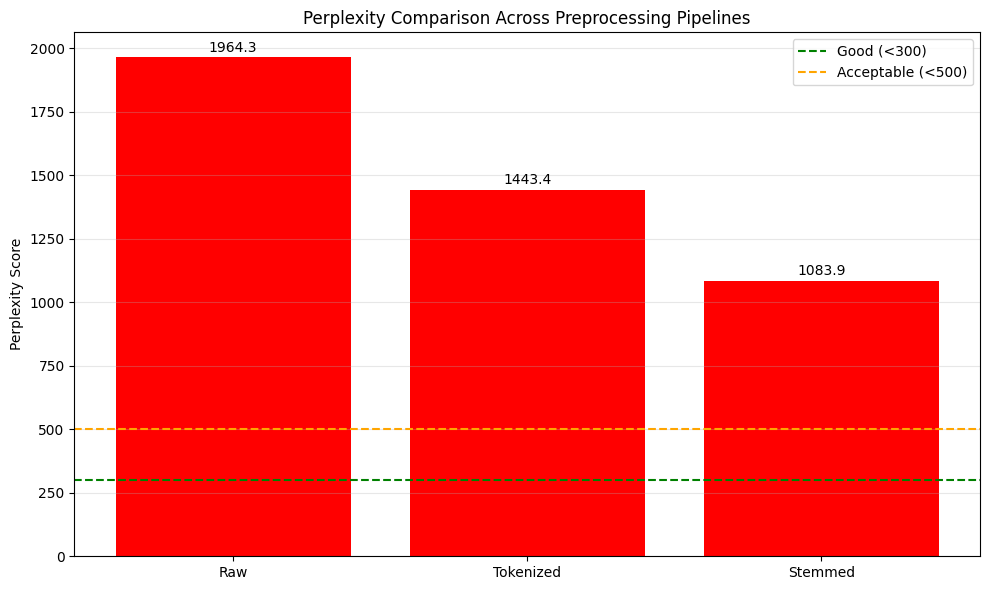


Comparative analysis complete. Chart saved as 'perplexity_comparison.png'


In [ ]:
import matplotlib.pyplot as plt
print("COMPARATIVE ANALYSIS")


def split_into_sentences(tokens):
    sentences = []
    current = []
    for token in tokens:
        current.append(token)
        if token == '</s>':
            if len(current) > 2:  # At least <s> word </s>
                sentences.append(current)
            current = []
    return sentences

def build_ngram_models(tokens):
    unigrams = Counter(tokens)
    bigrams = defaultdict(Counter)
    for i in range(len(tokens) - 1):
        bigrams[tokens[i]][tokens[i+1]] += 1
    trigrams = defaultdict(Counter)
    for i in range(len(tokens) - 2):
        trigrams[(tokens[i], tokens[i+1])][tokens[i+2]] += 1
    vocab = set(tokens)
    V = len(vocab)
    return unigrams, bigrams, trigrams, V, vocab

pipelines = {
    'Raw': 'raw.txt',
    'Tokenized': 'tokenized.txt',
    'Stemmed': 'stemmed.txt',
    'Lemmatized': 'lemmatized.txt'
}

pipeline_perplexities = {}

for name, filename in pipelines.items():
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            if name == 'Raw':
                text = f.read()
                text = re.sub(r'\[\d+\]\n', '', text)
                pipeline_tokens = []
                sentences = re.split(r'[۔.؟!]', text)
                for sent in sentences:
                    words = sent.strip().split()
                    if words:
                        pipeline_tokens.append('<s>')
                        pipeline_tokens.extend(words)
                        pipeline_tokens.append('</s>')
            else:
                pipeline_tokens = f.read().split()

        pipe_sentences = split_into_sentences(pipeline_tokens)
        if len(pipe_sentences) < 10:
            continue

        split_idx = int(len(pipe_sentences) * 0.8)
        pipe_train = [t for s in pipe_sentences[:split_idx] for t in s]
        pipe_test = [t for s in pipe_sentences[split_idx:] for t in s]

        u, b, t, v, _ = build_ngram_models(pipe_train)

        log_prob = 0
        n = 0
        total_u = sum(u.values())

        for i in range(len(pipe_test) - 2):
            if pipe_test[i] == '<s>' or pipe_test[i+1] == '<s>':
                continue
            w1, w2, w3 = pipe_test[i], pipe_test[i+1], pipe_test[i+2]

            # Backoff probability with Laplace smoothing
            if (w1, w2) in t and w3 in t[(w1, w2)]:
                prob = (t[(w1, w2)][w3] + 1) / (b.get(w1, {}).get(w2, 0) + v)
            elif w2 in b and w3 in b[w2]:
                prob = (b[w2][w3] + 1) / (u.get(w2, 0) + v)
            else:
                prob = (u.get(w3, 0) + 1) / (total_u + v)

            if prob > 0:
                log_prob += math.log(prob)
                n += 1

        pp = math.exp(-log_prob / n) if n > 0 else float('inf')
        pipeline_perplexities[name] = pp

    except Exception as e:
        print(f"Error with {name}: {e}")
        pipeline_perplexities[name] = None

# Display results
print("\nPerplexity by Preprocessing Pipeline:")
print("-" * 50)
print(f"{'Pipeline':15} {'Perplexity':12} {'Status':15}")
print("-" * 50)

for name in ['Raw', 'Tokenized', 'Stemmed', 'Lemmatized']:
    if name in pipeline_perplexities and pipeline_perplexities[name]:
        pp = pipeline_perplexities[name]
        if pp < 300:
            status = " Good"
        elif pp < 500:
            status = "Acceptable"
        else:
            status = "Poor"
        print(f"{name:15} {pp:10.2f}    {status:15}")

plt.figure(figsize=(10, 6))
names = []
values = []
colors = []

for name in ['Raw', 'Tokenized', 'Stemmed', 'Lemmatized']:
    if name in pipeline_perplexities and pipeline_perplexities[name]:
        names.append(name)
        pp = pipeline_perplexities[name]
        values.append(pp)
        if pp < 300:
            colors.append('green')
        elif pp < 500:
            colors.append('orange')
        else:
            colors.append('red')

plt.bar(names, values, color=colors)
plt.ylabel('Perplexity Score')
plt.title('Perplexity Comparison Across Preprocessing Pipelines')
plt.axhline(y=300, color='green', linestyle='--', label='Good (<300)')
plt.axhline(y=500, color='orange', linestyle='--', label='Acceptable (<500)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(values):
    plt.text(i, v + 10, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('perplexity_comparison.png', dpi=150)
plt.show()

print("\nComparative analysis complete. Chart saved as 'perplexity_comparison.png'")

In [394]:
!pip install ipywidgets
!jupyter nbextension enable --py widgetsnbextension

import ipywidgets as widgets
from IPython.display import display, clear_output

style = """
<style>
.urdu-text {
    direction: rtl;
    text-align: right;
    font-family: 'Jameel Noori Nastaleeq', 'Noto Nastaliq Urdu', 'Arial';
    font-size: 18px;
    line-height: 2;
    padding: 20px;
    background: #f8f9fa;
    border-radius: 10px;
    border: 1px solid #dee2e6;
    margin: 10px 0;
}
</style>
"""
display(widgets.HTML(style))

display(widgets.HTML("<h2 style='text-align:center;'>Urdu News Article Generator</h2>"))

model_dropdown = widgets.Dropdown(
    options=['Bigram', 'Trigram'],
    value='Trigram',
    description='Model:',
    layout=widgets.Layout(width='300px')
)

seed_input = widgets.Textarea(
    value='پاکستان میں مہنگائی کی شرح میں اضافہ',
    description='Seed:',
    layout=widgets.Layout(width='100%', height='100px')
)

seed_input.style = {'font_family': 'Jameel Noori Nastaleeq', 'font_size': '16px'}

generate_button = widgets.Button(
    description='Generate Article',
    button_style='primary',
    layout=widgets.Layout(width='200px')
)

output_area = widgets.Output()
stats_label = widgets.HTML("")

def on_generate(b):
    with output_area:
        clear_output()

        model = model_dropdown.value.lower()
        seed = seed_input.value.strip()

        words = seed.split()
        if len(words) < 5 or len(words) > 8:
            print(f"Error: Seed must be 5-8 words. Current: {len(words)}")
            return

        print(f"Generating with {model} model...")
        print(f"Seed: {seed}")
        print("-" * 50)

        article = generate_article(seed, model_type=model, min_words=200, max_words=300)

        display(widgets.HTML(f'<div class="urdu-text">{article}</div>'))

        word_count = len(article.split())
        sentence_count = article.count('۔')
        stats_label.value = f"<b>Words:</b> {word_count} | <b>Sentences:</b> {sentence_count}"

generate_button.on_click(on_generate)

ui = widgets.VBox([
    model_dropdown,
    seed_input,
    generate_button,
    stats_label,
    output_area
], layout=widgets.Layout(padding='20px'))

display(ui)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.8 MB/s eta 0:00:00
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


HTML(value="\n<style>\n.urdu-text {\n    direction: rtl;\n    text-align: right;\n    font-family: 'Jameel Noo…

HTML(value="<h2 style='text-align:center;'>Urdu News Article Generator</h2>")